# Multivariate Analysis

In [2]:
#library import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the dataset
df=pd.read_csv("Screen_Time_Cleaned.csv")
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Level,Health_Risk_Flag,Usage_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,11-15,Medium,At risk,More Recreational
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-15,Medium,At risk,More Recreational
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,16-18,Medium,At risk,More Recreational
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,11-15,Low,No risk,More Recreational
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-15,High,At risk,More Recreational


1. Age band x Device x screen Time


Primary_Device    Laptop  Smartphone        TV    Tablet
Age_Band                                                
11-15           4.390510    4.539468  4.550867  4.458286
16-18           4.582456    4.521379  4.537902  4.525496
6-10                 NaN    4.003200  3.957223  3.949927


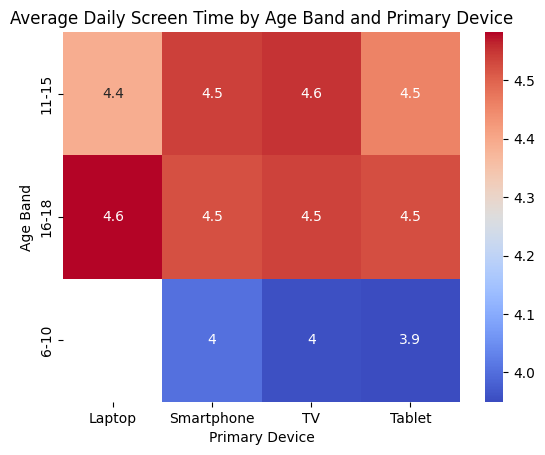

In [15]:
multi_data=df.groupby(["Age_Band", "Primary_Device"])["Avg_Daily_Screen_Time_hr"].mean()

multi_pivot=multi_data.unstack()
print(multi_pivot)

plt.figure()
sns.heatmap(multi_pivot, annot=True, cmap="coolwarm")
plt.title("Average Daily Screen Time by Age Band and Primary Device")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.show()


##### Insights:
 The 16–18 age group has the highest screen time across most devices.
 Smartphones and TVs are the most used devices.
 Tablet usage is comparatively lower.
 Younger children (6–10) spend less time on screens.

2. age x device x exceeded limit

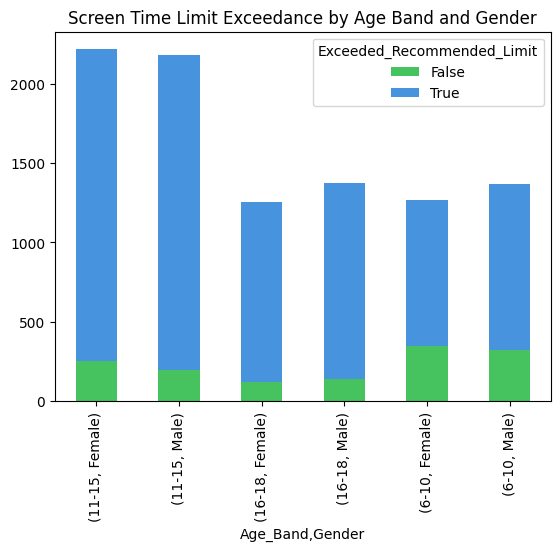

In [37]:
multi_limit=pd.crosstab([df["Age_Band"], df["Gender"]],df["Exceeded_Recommended_Limit"])

multi_limit.plot(kind="bar", stacked=True , color=["#46C25F", "#4893DD"])
plt.title("Screen Time Limit Exceedance by Age Band and Gender")
# plt.xticks(rotation=50)
plt.show()

##### Insight:

Most children exceed the recommended screen time limit.
The 11–15 age group has the highest number of children exceeding limits.
There is no major difference between males and females.

# Cohort Analysis

Age band vs Screen time

Age_Band
11-15    4.502687
16-18    4.537047
6-10     3.973999
Name: Avg_Daily_Screen_Time_hr, dtype: float64


C:\Users\deepa\AppData\Local\Temp\ipykernel_58284\3125538863.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Age_Screen.index, y=Age_Screen.values, palette="Set1")


<Axes: xlabel='Age_Band'>

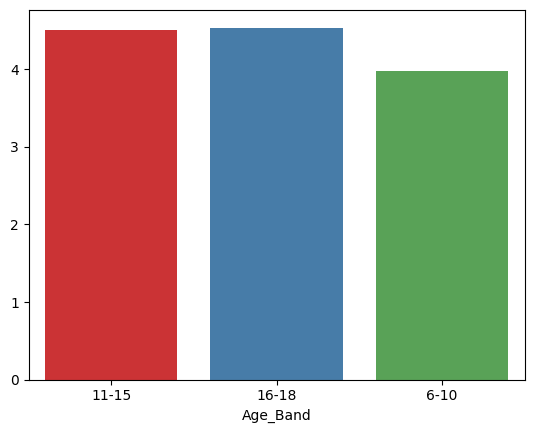

In [20]:
Age_Screen=df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()
print(Age_Screen)

plt.figure()
sns.barplot(x=Age_Screen.index, y=Age_Screen.values, palette="Set1")

##### Insight:

The 11–15 age group shows the highest exceedance.
Even younger children (6–10) are crossing limits.
16–18 group also shows high usage.

Age Band vs Exceeded Limit

Exceeded_Recommended_Limit  False  True 
Age_Band                                
11-15                         448   3951
16-18                         259   2372
6-10                          669   1969


<Figure size 640x480 with 0 Axes>

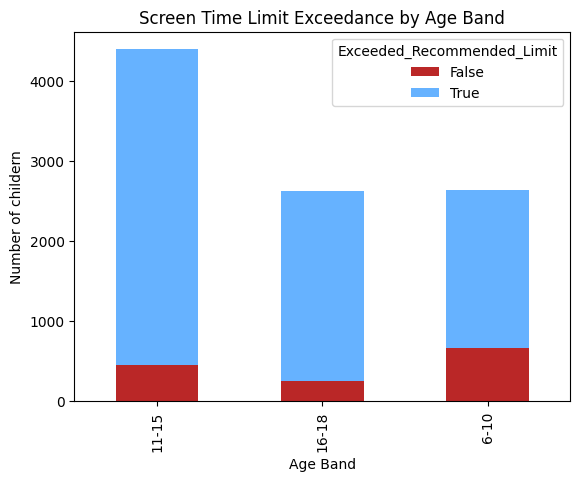

In [34]:
Age_Limit=pd.crosstab(df["Age_Band"], df["Exceeded_Recommended_Limit"])
print(Age_Limit)

plt.figure()
Age_Limit.plot(kind="bar", stacked=True, color=["#BA2727", "#66B2FF"])
plt.title("Screen Time Limit Exceedance by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of childern")
plt.show()

##### Insight:
In every age group, more children exceed the limit than stay within it.
This shows that excessive screen usage is common across all groups.

Age Band vs Usage type

Usage_Type  More Educational  More Recreational
Age_Band                                       
11-15                    120               4279
16-18                     56               2575
6-10                    1407               1231


<Axes: xlabel='Age_Band', ylabel='Avg_Daily_Screen_Time_hr'>

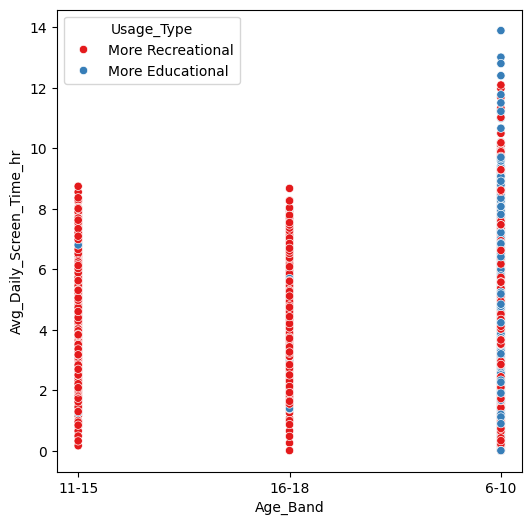

In [46]:
Age_usage=pd.crosstab(df["Age_Band"], df["Usage_Type"])
print(Age_usage)

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="Age_Band", y="Avg_Daily_Screen_Time_hr", hue="Usage_Type", palette="Set1")

##### Insight:
Screen time is consistently high across all age groups.
There is no major variation, meaning the issue is widespread.